# Freight Rate — Exploratory Data Analysis

What the data says, and what each finding forces the model to do.

Every conclusion here is reproduced by the pipeline in `src/freight_rate/`. This notebook
reads from those modules rather than reimplementing them, so nothing can drift between
what is shown here and what actually runs.

**Contents**

1. [The shape of the problem](#1) — a forward-in-time holdout, not a random one
2. [The target](#2) — a long right tail
3. [`quote_signal`](#3) — the finding that reframes the task
4. [Data quality](#4) — sign errors, gaps, a cap
5. [`market_index`](#5) — a daily series wearing a per-load disguise
6. [Distribution shift](#6) — the market moves between train and validation
7. [Cold start](#7) — eight cities that appear only at prediction time
8. [Equipment](#8) — the quote does not price it
9. [Temporal structure](#9) — autocorrelation and a weekly cycle
10. [What this implies](#10)

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Read from the pipeline package so this notebook cannot drift from what runs.
# `pip install -e .` makes it importable from anywhere, so no sys.path juggling.
from freight_rate import cleaning, loading, market

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#E3E9EA",
    "grid.linewidth": 0.8,
    "font.size": 10,
})
TEAL, RUST, AMBER, SLATE = "#064A56", "#B3261E", "#B26A00", "#607478"

train_raw = loading.load_train()
valid_raw = loading.load_validation()
train = cleaning.clean(train_raw)
valid = cleaning.clean(valid_raw)

train["rpm"] = train.posted_rate / train.distance
print(f"train      {train.shape}   {train.date.min():%Y-%m-%d} to {train.date.max():%Y-%m-%d}")
print(f"validation {valid.shape}   {valid.date.min():%Y-%m-%d} to {valid.date.max():%Y-%m-%d}")

train      (48000, 17)   2025-01-01 to 2025-10-31
validation (12000, 15)   2025-11-01 to 2025-12-31


<a id="1"></a>
## 1. The shape of the problem

Training stops on 31 October; prediction starts on 1 November. The holdout is strictly
forward in time, which is the single most important structural fact about this task —
it rules out random cross-validation before any modelling decision is made.

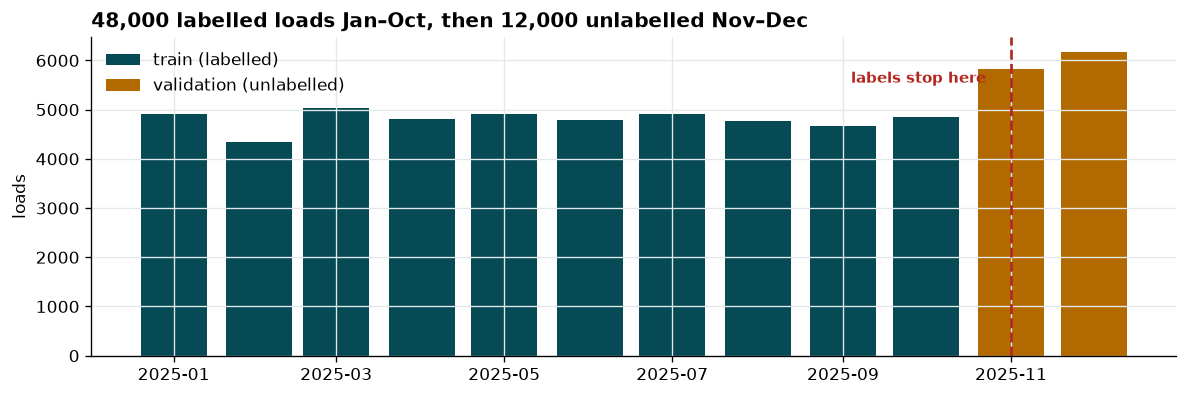

In [2]:
fig, ax = plt.subplots(figsize=(10, 3.4))
counts = pd.concat([
    train.assign(split="train"),
    valid.assign(split="validation"),
]).groupby([pd.Grouper(key="date", freq="MS"), "split"]).size().unstack(fill_value=0)

ax.bar(counts.index, counts.get("train", 0), width=24, color=TEAL, label="train (labelled)")
ax.bar(counts.index, counts.get("validation", 0), width=24, color=AMBER, label="validation (unlabelled)")
ax.axvline(pd.Timestamp("2025-11-01"), color=RUST, linestyle="--", linewidth=1.6)
ax.annotate("labels stop here", xy=(pd.Timestamp("2025-11-01"), counts.values.max() * 0.9),
            xytext=(-96, 0), textcoords="offset points", color=RUST, fontweight="bold", fontsize=9)
ax.set_ylabel("loads")
ax.set_title("48,000 labelled loads Jan–Oct, then 12,000 unlabelled Nov–Dec", loc="left", fontweight="bold")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

<a id="2"></a>
## 2. The target

`posted_rate` is the total dollars paid for a load, so it scales with trip length —
correlation with `distance` is 0.91. Dividing it out gives rate-per-mile, which is the
quantity actually worth modelling. Its tail is long: a median of \$2.15/mile, but the
top 0.7% of loads run past \$4 and reach \$14.

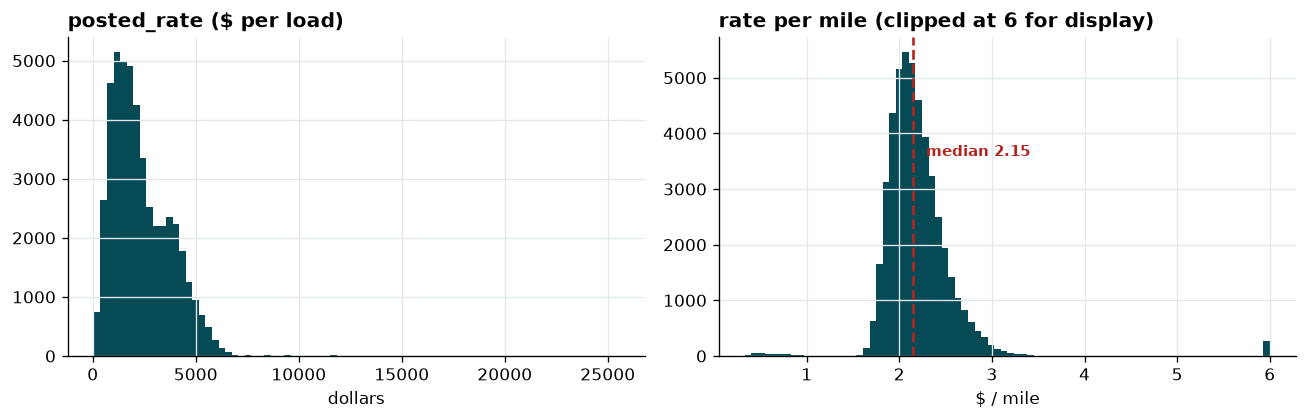

correlation, distance vs posted_rate : 0.909
share of loads above $4/mile         : 0.71%
max rate per mile                    : $14.13


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

axes[0].hist(train.posted_rate, bins=80, color=TEAL)
axes[0].set_title("posted_rate ($ per load)", loc="left", fontweight="bold")
axes[0].set_xlabel("dollars")

axes[1].hist(train.rpm.clip(upper=6), bins=80, color=TEAL)
axes[1].axvline(train.rpm.median(), color=RUST, linestyle="--", linewidth=1.6)
axes[1].annotate(f"median {train.rpm.median():.2f}", xy=(train.rpm.median(), 0),
                 xytext=(8, 120), textcoords="offset points", color=RUST, fontweight="bold", fontsize=9)
axes[1].set_title("rate per mile (clipped at 6 for display)", loc="left", fontweight="bold")
axes[1].set_xlabel("$ / mile")
plt.tight_layout()
plt.show()

print(f"correlation, distance vs posted_rate : {train.distance.corr(train.posted_rate):.3f}")
print(f"share of loads above $4/mile         : {(train.rpm > 4).mean():.2%}")
print(f"max rate per mile                    : ${train.rpm.max():.2f}")

<a id="3"></a>
## 3. `quote_signal` — the finding that reframes the task

A correlation matrix says `quote_signal` is worthless: its correlation with
`posted_rate` is **−0.04**. That is misleading. The column is a dollars-per-mile quote,
so it acts *multiplicatively* with distance, and the heavy tail crushes the linear
correlation.

Multiply it out and the picture inverts.

In [4]:
baseline = train.distance * train.quote_signal
ratio = train.posted_rate / baseline
ape = (baseline - train.posted_rate).abs() / train.posted_rate * 100

print(f"correlation, quote_signal vs posted_rate : {train.quote_signal.corr(train.posted_rate):+.3f}   <- looks useless")
print()
print("but  predicted = distance x quote_signal, with no model at all:")
print(f"    within  2% of the actual rate : {(ratio.sub(1).abs() <= 0.02).mean():.1%} of loads")
print(f"    within 10% of the actual rate : {(ratio.sub(1).abs() <= 0.10).mean():.1%} of loads")
error = (baseline - train.posted_rate).abs()
print(f"    median absolute % error        : {ape.median():>8.2f}%")
print(f"    mean absolute % error  (MAPE)  : {ape.mean():>8.2f}%")
print(f"    median absolute error          : ${error.median():>8,.2f}")
print(f"    mean absolute error    (MAE)   : ${error.mean():>8,.2f}")

correlation, quote_signal vs posted_rate : -0.040   <- looks useless

but  predicted = distance x quote_signal, with no model at all:
    within  2% of the actual rate : 49.9% of loads
    within 10% of the actual rate : 66.9% of loads
    median absolute % error        :     2.02%
    mean absolute % error  (MAPE)  :    11.37%
    median absolute error          : $   55.55
    mean absolute error    (MAE)   : $  232.26


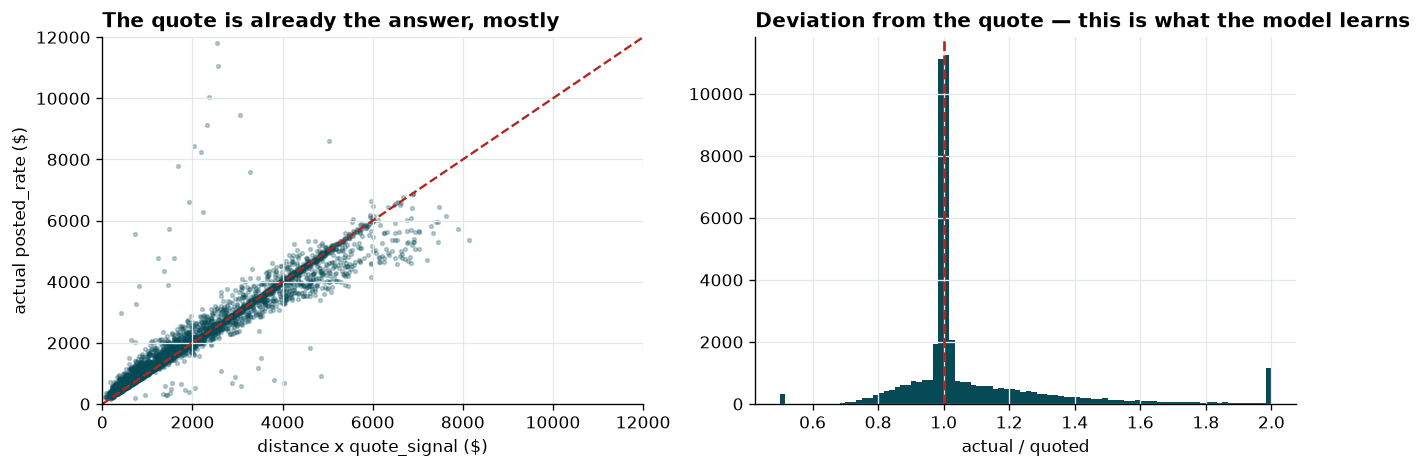

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))

sample = train.sample(4000, random_state=0)
axes[0].scatter(sample.distance * sample.quote_signal, sample.posted_rate,
                s=5, alpha=0.25, color=TEAL)
limit = 12000
axes[0].plot([0, limit], [0, limit], color=RUST, linewidth=1.4, linestyle="--")
axes[0].set_xlim(0, limit); axes[0].set_ylim(0, limit)
axes[0].set_xlabel("distance x quote_signal ($)")
axes[0].set_ylabel("actual posted_rate ($)")
axes[0].set_title("The quote is already the answer, mostly", loc="left", fontweight="bold")

axes[1].hist(ratio.clip(0.5, 2.0), bins=90, color=TEAL)
axes[1].axvline(1.0, color=RUST, linestyle="--", linewidth=1.6)
axes[1].set_xlabel("actual / quoted")
axes[1].set_title("Deviation from the quote — this is what the model learns", loc="left", fontweight="bold")
plt.tight_layout()
plt.show()

Loads scatter on *both* sides of the line — 57.8% above, 42.2% below — so the quote is a
central estimate, not a floor. What is lopsided is how far each side reaches: the 1st
percentile sits 27% below the quote, the 99th sits 155% above, and the extreme runs to
11.4×. Skew is **6.64**.

That is why the model predicts `log(posted_rate / (distance × quote_signal))` rather
than the rate itself. The **ratio** means it only has to learn the deviation from a
quote that is already within 2% half the time. The **log** does two things: it makes a
doubling and a halving equally wrong (±0.69, rather than +1.00 against −0.50), and it
stops the worst load steering the fit — under squared error that load outweighs a
typical one by 10,757× on the raw ratio but only 651× in log space. Skew falls from
6.64 to 0.96.

<a id="4"></a>
## 4. Data quality

Three issues, all in the load-attribute columns rather than the target.

In [6]:
issues = pd.DataFrame([
    {"issue": "negative weight",
     "train": int((train_raw.weight < 0).sum()), "validation": int((valid_raw.weight < 0).sum()),
     "handling": "sign error - abs() and flag"},
    {"issue": "missing weight",
     "train": int(train_raw.weight.isna().sum()), "validation": int(valid_raw.weight.isna().sum()),
     "handling": "left as NaN, model splits on missingness"},
    {"issue": "missing market_index",
     "train": int(train_raw.market_index.isna().sum()), "validation": int(valid_raw.market_index.isna().sum()),
     "handling": "filled from the same date's mean"},
])
display(issues)

# Negative weights are sign errors, not corrupt records: their magnitudes match the rest.
negative = train_raw.loc[train_raw.weight < 0, "weight"].abs()
positive = train_raw.loc[train_raw.weight > 0, "weight"]
print(f"median |weight| among negatives : {negative.median():,.0f}")
print(f"median  weight  among positives : {positive.median():,.0f}")
print("-> same distribution, so the magnitude is trustworthy and only the sign is wrong")

,issue,train,validation,handling
0,negative weight,292,145,sign error - abs() and flag
1,missing weight,300,165,"left as NaN, model splits on missingness"
2,missing market_index,374,249,filled from the same date's mean


median |weight| among negatives : 31,822
median  weight  among positives : 31,494
-> same distribution, so the magnitude is trustworthy and only the sign is wrong


<a id="5"></a>
## 5. `market_index` — a daily series wearing a per-load disguise

On a day with ~157 loads there are ~155 distinct `market_index` values, which looks
like a per-load attribute. It is not. Decomposing the variance shows the date explains
almost all of it.

In [7]:
daily = train.groupby("date").market_index.transform("mean")
grand = train.market_index.mean()
explained = ((daily - grand) ** 2).sum() / ((train.market_index - grand) ** 2).sum()

print(f"variance explained by date alone : {explained:.1%}")
print(f"left over as within-day scatter  : {1 - explained:.1%}")
print()
print(f"std of the daily means  : {train.groupby('date').market_index.mean().std():.4f}")
print(f"avg within-day std      : {train.groupby('date').market_index.std().mean():.4f}")

# The leftover correlates with nothing about the load.
deviation = train.market_index - daily
print("\ncorrelation of the within-day leftover with:")
for column in ["distance", "weight", "quote_signal", "posted_rate"]:
    subset = train.dropna(subset=[column])
    print(f"    {column:13s} {np.corrcoef(subset[column], deviation[subset.index])[0, 1]:+.4f}")

variance explained by date alone : 97.8%
left over as within-day scatter  : 2.2%

std of the daily means  : 0.1665
avg within-day std      : 0.0248

correlation of the within-day leftover with:
    distance      -0.0041
    weight        +0.0093
    quote_signal  +0.0107
    posted_rate   +0.0024


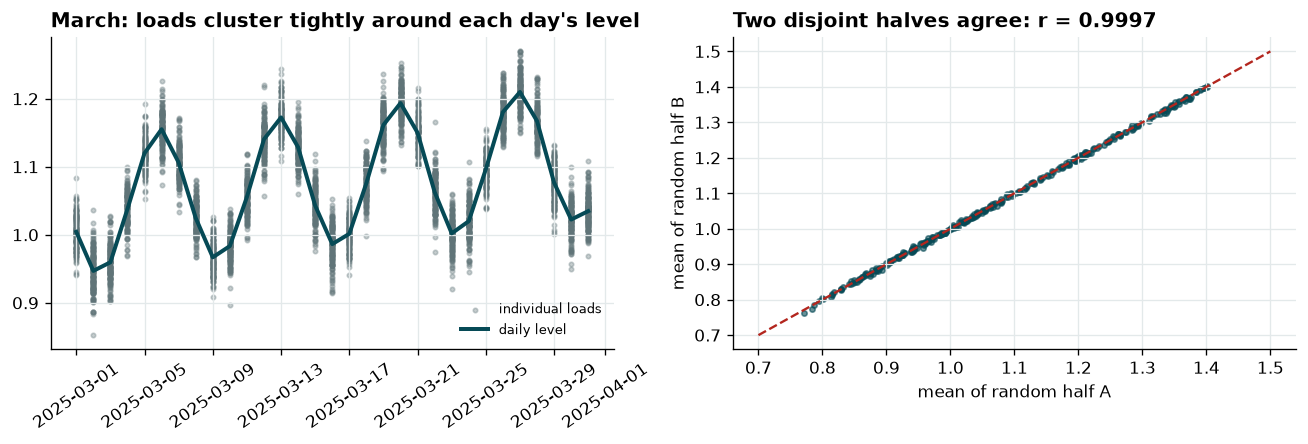

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

window = train[train.date.between("2025-03-01", "2025-03-31")]
axes[0].scatter(window.date, window.market_index, s=7, alpha=0.35, color=SLATE, label="individual loads")
levels = window.groupby("date").market_index.mean()
axes[0].plot(levels.index, levels.values, color=TEAL, linewidth=2.4, label="daily level")
axes[0].set_title("March: loads cluster tightly around each day's level", loc="left", fontweight="bold")
axes[0].tick_params(axis="x", rotation=35)
axes[0].legend(frameon=False, fontsize=8)

# Split-half test: two disjoint samples of the same day must agree.
rng = np.random.default_rng(0)
halves = train.assign(half=rng.integers(0, 2, len(train)))
pivot = halves.pivot_table(index="date", columns="half", values="market_index", aggfunc="mean")
axes[1].scatter(pivot[0], pivot[1], s=10, alpha=0.6, color=TEAL)
axes[1].plot([0.7, 1.5], [0.7, 1.5], color=RUST, linestyle="--", linewidth=1.4)
axes[1].set_xlabel("mean of random half A"); axes[1].set_ylabel("mean of random half B")
axes[1].set_title(f"Two disjoint halves agree: r = {pivot[0].corr(pivot[1]):.4f}", loc="left", fontweight="bold")
plt.tight_layout()
plt.show()

Two completely different sets of loads from the same day independently produce the same
number. That makes the daily level a property of the *day*, not of the loads — which is
what allows it to be recovered for December, where `december_chart_inputs.csv` ships
without the column entirely.

<a id="6"></a>
## 6. Distribution shift

`market_index` does not merely move — it occupies a different range in the prediction
window than in training. Anything the model learns about its upper half is unusable.

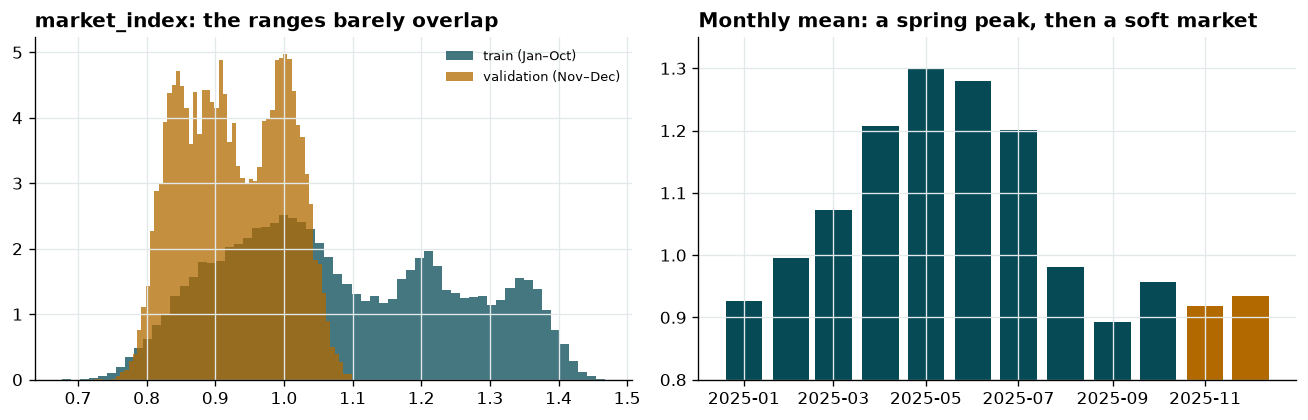

train      mean 1.083   range 0.68–1.47
validation mean 0.927   range 0.72–1.10


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

axes[0].hist(train.market_index, bins=60, alpha=0.75, color=TEAL, label="train (Jan–Oct)", density=True)
axes[0].hist(valid.market_index, bins=60, alpha=0.75, color=AMBER, label="validation (Nov–Dec)", density=True)
axes[0].set_title("market_index: the ranges barely overlap", loc="left", fontweight="bold")
axes[0].legend(frameon=False, fontsize=8)

monthly = pd.concat([train, valid]).groupby(pd.Grouper(key="date", freq="MS")).market_index.mean()
colours = [TEAL if index < pd.Timestamp("2025-11-01") else AMBER for index in monthly.index]
axes[1].bar(monthly.index, monthly.values, width=24, color=colours)
axes[1].set_title("Monthly mean: a spring peak, then a soft market", loc="left", fontweight="bold")
axes[1].set_ylim(0.8, 1.35)
plt.tight_layout()
plt.show()

print(f"train      mean {train.market_index.mean():.3f}   range {train.market_index.min():.2f}–{train.market_index.max():.2f}")
print(f"validation mean {valid.market_index.mean():.3f}   range {valid.market_index.min():.2f}–{valid.market_index.max():.2f}")

<a id="7"></a>
## 7. Cold start — eight cities appear only at prediction time

This is the quietest way to break a submission. Any encoding built on city *names*
meets categories it has never seen.

In [10]:
train_cities = set(train.pickup) | set(train.delivery)
valid_cities = set(valid.pickup) | set(valid.delivery)
unseen = sorted(valid_cities - train_cities)

print(f"cities in train      : {len(train_cities)}")
print(f"cities in validation : {len(valid_cities)}")
print(f"unseen at prediction : {len(unseen)} -> {', '.join(unseen)}")

affected = valid[valid.pickup.isin(unseen) | valid.delivery.isin(unseen)]
print(f"\nvalidation loads touching an unseen city: {len(affected):,} ({len(affected) / len(valid):.1%})")
print("\nCoordinates are supplied for these cities, and are fixed per city across the")
print("dataset - so geography-derived features generalise where names cannot.")

cities in train      : 64
cities in validation : 72
unseen at prediction : 8 -> Allentown, Charlotte, Chicago, Jackson, Knoxville, Laredo, Norfolk, San Diego

validation loads touching an unseen city: 1,447 (12.1%)

Coordinates are supplied for these cities, and are fixed per city across the
dataset - so geography-derived features generalise where names cannot.


<a id="8"></a>
## 8. Equipment — the quote does not price it

`quote_signal` is essentially flat across trailer types, but realised rates are not.
The gap is not a uniform shift: the *typical* load of every type lands on its quote, and
what changes is how often a load escapes it.

In [11]:
comparison = pd.DataFrame({
    "mean quote_signal": train.groupby("equipment").quote_signal.mean(),
    "median actual $/mile": train.groupby("equipment").rpm.median(),
})
residual = train.rpm / train.quote_signal
core = residual.between(0.5, 2.0)
comparison["median actual/quote"] = residual[core].groupby(train.equipment[core]).median()
comparison["share paying >20% over quote"] = (residual[core] > 1.2).groupby(train.equipment[core]).mean()
display(comparison.round(4))

,mean quote_signal,median actual $/mile,median actual/quote,share paying >20% over quote
equipment,,,,
Dry Van,2.0474,2.0462,0.9999,0.0994
Flatbed,2.0795,2.2197,1.0068,0.1947
Reefer,2.0840,2.3115,1.0102,0.2627


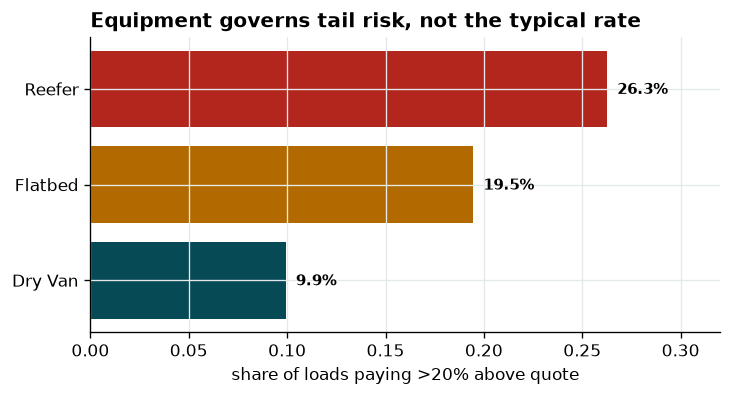

In [12]:
fig, ax = plt.subplots(figsize=(6.2, 3.4))
share = (residual[core] > 1.2).groupby(train.equipment[core]).mean().sort_values()
ax.barh(share.index, share.values, color=[TEAL, AMBER, RUST])
for name, value in share.items():
    ax.annotate(f"{value:.1%}", xy=(value, name), xytext=(6, -3),
                textcoords="offset points", fontweight="bold", fontsize=9)
ax.set_xlim(0, 0.32)
ax.set_xlabel("share of loads paying >20% above quote")
ax.set_title("Equipment governs tail risk, not the typical rate", loc="left", fontweight="bold")
plt.tight_layout()
plt.show()

A Reefer is **2.6×** as likely as a Dry Van to blow past its quote. That is an argument
for a tail-aware loss or for modelling the deviation separately, not for a simple
per-equipment offset.

<a id="9"></a>
## 9. Temporal structure

Enough autocorrelation to invalidate random cross-validation, and a clear weekly cycle.

,daily median $/mile,daily market level
lag 1,0.844,0.927
lag 2,0.771,0.768
lag 3,0.723,0.640
lag 7,0.789,0.969
lag 14,0.704,0.924
lag 30,0.470,0.541


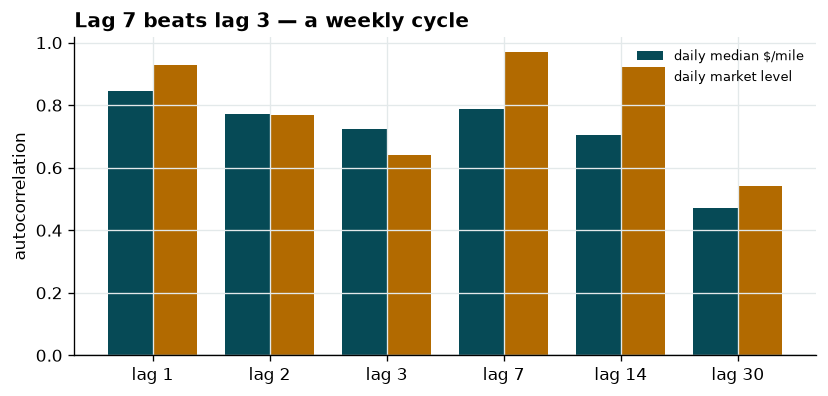

lag-1 autocorrelation of daily $/mile : +0.844
-> a shuffled split trains on Tuesday and tests on Wednesday, which share a market level


In [13]:
daily_rpm = train.groupby("date").rpm.median()
daily_market = train.groupby("date").market_index.mean()

lags = [1, 2, 3, 7, 14, 30]
acf = pd.DataFrame({
    "daily median $/mile": [daily_rpm.autocorr(lag) for lag in lags],
    "daily market level": [daily_market.autocorr(lag) for lag in lags],
}, index=[f"lag {lag}" for lag in lags])
display(acf.round(3))

fig, ax = plt.subplots(figsize=(7, 3.4))
width = 0.38
positions = np.arange(len(lags))
ax.bar(positions - width / 2, acf.iloc[:, 0], width, color=TEAL, label=acf.columns[0])
ax.bar(positions + width / 2, acf.iloc[:, 1], width, color=AMBER, label=acf.columns[1])
ax.set_xticks(positions); ax.set_xticklabels(acf.index)
ax.axhline(0, color=SLATE, linewidth=0.8)
ax.set_ylabel("autocorrelation")
ax.set_title("Lag 7 beats lag 3 — a weekly cycle", loc="left", fontweight="bold")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

print(f"lag-1 autocorrelation of daily $/mile : {daily_rpm.autocorr(1):+.3f}")
print("-> a shuffled split trains on Tuesday and tests on Wednesday, which share a market level")

<a id="10"></a>
## 10. What this implies

| Finding | Consequence for the model |
|---|---|
| Holdout is forward in time; lag-1 autocorrelation +0.84 | Forward-chaining validation. Random k-fold understates MAE by 33.9% |
| `distance × quote_signal` is within 2% on half the loads | Predict the log ratio against that baseline, not the raw rate |
| Target tail reaches \$14/mile | Log target, so 0.7% of rows do not dominate the loss |
| `market_index` is 97.8% a daily series | Recover the daily level; use it for December, where the column is absent |
| Its range shifts train → validation | Do not lean on the upper half of the learned range |
| 8 cities unseen until prediction | Geography from coordinates, never from city names |
| Equipment drives tail risk, not level | Let the model learn it as an interaction, not a fixed offset |
| Lag-7 > lag-3 autocorrelation | Day-of-week as a cyclical feature — and it extrapolates into December |

The last two rows are what the December chart tests. Encoding the date as an ordinal or
a month index produces a flat line, because both fall beyond the training horizon; see
`reports/figures/december_encoding_comparison.png` and
[`src/freight_rate/features/temporal.py`](../src/freight_rate/features/temporal.py).